## Import packages

In [128]:
import pandas as pd

#load dataset into the Dataframe
df = pd.read_csv("data/Building_Energy_Benchmarking_Data__2015-Present_20250224.csv")


In [129]:
print(df.info())
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30616 entries, 0 to 30615
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    30616 non-null  int64  
 1   DataYear                         30616 non-null  int64  
 2   BuildingName                     30616 non-null  object 
 3   BuildingType                     30616 non-null  object 
 4   TaxParcelIdentificationNumber    30616 non-null  object 
 5   Address                          30616 non-null  object 
 6   City                             30616 non-null  object 
 7   State                            30616 non-null  object 
 8   ZipCode                          30616 non-null  int64  
 9   Latitude                         30616 non-null  float64
 10  Longitude                        30616 non-null  float64
 11  Neighborhood                     30616 non-null  object 
 12  CouncilDistrictCod

(30616, 46)

In [130]:
# Check for missing values, show only columns with missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

NumberofFloors                        83
NumberofBuildings                    294
ENERGYSTARScore                     7917
SiteEUIWN(kBtu/sf)                  1166
SiteEUI(kBtu/sf)                     856
SiteEnergyUse(kBtu)                  851
SiteEnergyUseWN(kBtu)               1161
SourceEUIWN(kBtu/sf)                1166
SourceEUI(kBtu/sf)                   856
LargestPropertyUseType                 8
LargestPropertyUseTypeGFA              3
SecondLargestPropertyUseType       13102
SecondLargestPropertyUseTypeGFA    13102
ThirdLargestPropertyUseType        23927
ThirdLargestPropertyUseTypeGFA     24088
Electricity(kWh)                     541
SteamUse(kBtu)                     29559
NaturalGas(therms)                 11448
ComplianceIssue                      345
Electricity(kBtu)                    541
NaturalGas(kBtu)                   11448
TotalGHGEmissions                    457
GHGEmissionsIntensity                459
dtype: int64


#### info on the dataset
dataframe has the shape (30,616 rows, 46 columns) and some columns contain missing values, it's essential to handle them before proceeding with preprocessing. The missing values list returns the columns with missing values and the number of missing values in each column.

## EDA
There are 32 columns of with datatype is numerals and 14 columns that are categorical values including boolean.
Generates a heatmap using seaborn to visualize missing values in the dataframe (df)

In [131]:
# select only numerical features
numerical_features = df.select_dtypes(include=['number']).columns

print(len(numerical_features))
list(numerical_features)

32


['OSEBuildingID',
 'DataYear',
 'ZipCode',
 'Latitude',
 'Longitude',
 'CouncilDistrictCode',
 'YearBuilt',
 'NumberofFloors',
 'NumberofBuildings',
 'PropertyGFATotal',
 'PropertyGFABuildings',
 'PropertyGFAParking',
 'SelfReportGFATotal',
 'SelfReportGFABuildings',
 'SelfReportParking',
 'ENERGYSTARScore',
 'SiteEUIWN(kBtu/sf)',
 'SiteEUI(kBtu/sf)',
 'SiteEnergyUse(kBtu)',
 'SiteEnergyUseWN(kBtu)',
 'SourceEUIWN(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'LargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'Electricity(kWh)',
 'SteamUse(kBtu)',
 'NaturalGas(therms)',
 'Electricity(kBtu)',
 'NaturalGas(kBtu)',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity']

In [132]:
# select only categorical features
categorical_features = df.select_dtypes(include=["object", "category", "bool"]).columns
print(len(categorical_features))

list(categorical_features)

14


['BuildingName',
 'BuildingType',
 'TaxParcelIdentificationNumber',
 'Address',
 'City',
 'State',
 'Neighborhood',
 'EPAPropertyType',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType',
 'ComplianceStatus',
 'ComplianceIssue',
 'Demolished']

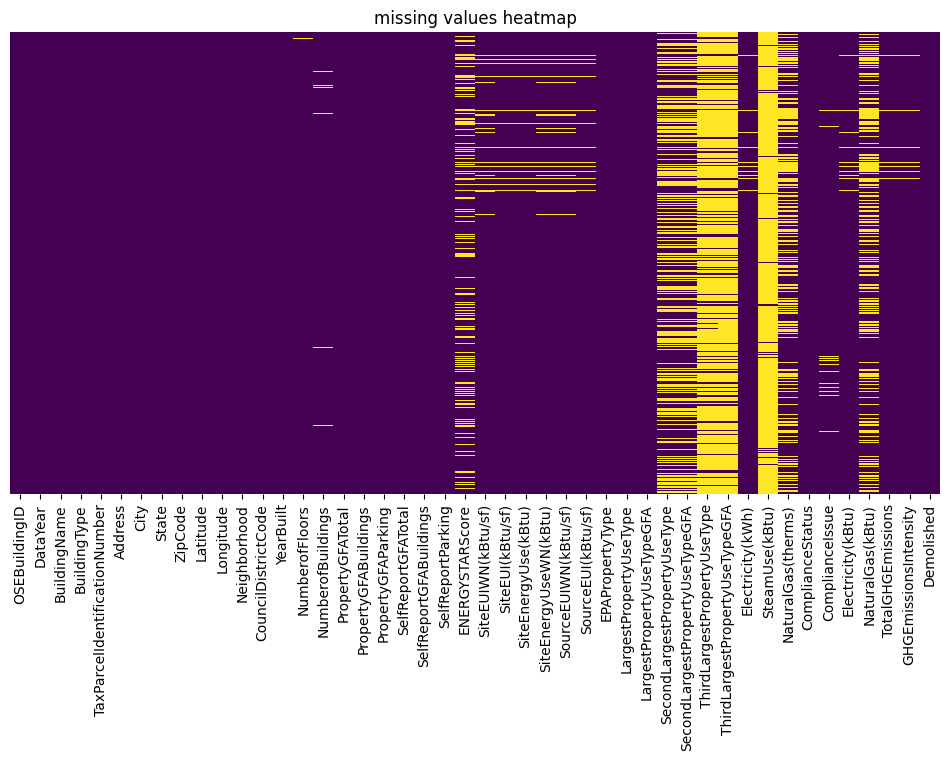

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# set figure size
plt.figure(figsize=(12,6))

# create heatmap
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)

# show plot
plt.title("missing values heatmap")
plt.show()


#### Drop columns
Some of the columns we will drop because of high percentage of missing values. Some columns that are redundant will also be dropped.

In [134]:

cols_to_drop = ['BuildingName',
 'Address',
 'City',
 'State',
 'Neighborhood',
 'EPAPropertyType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType',
 'SecondLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseTypeGFA',
 'ComplianceStatus',
 'ComplianceIssue',
 'SourceEUIWN(kBtu/sf)',
 'ZipCode',
 'Latitude',
 'Longitude',
 'CouncilDistrictCode',
  'SiteEUI(kBtu/sf)',
 'SiteEnergyUse(kBtu)', 'SteamUse(kBtu)','NaturalGas(therms)', 'Electricity(kBtu)', 'NaturalGas(kBtu)','TaxParcelIdentificationNumber']
df = df.drop(columns=cols_to_drop, errors='ignore')
 

In [135]:
# Calculate and add BuildingAge column
df["BuildingAge"] = df["DataYear"] - df["YearBuilt"]
df.drop(columns=["YearBuilt"], inplace=True)

In [136]:
print(df.columns)
len(df.columns)

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'NumberofFloors',
       'NumberofBuildings', 'PropertyGFATotal', 'PropertyGFABuildings',
       'PropertyGFAParking', 'SelfReportGFATotal', 'SelfReportGFABuildings',
       'SelfReportParking', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)',
       'SiteEnergyUseWN(kBtu)', 'SourceEUI(kBtu/sf)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'Electricity(kWh)', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Demolished', 'BuildingAge'],
      dtype='object')


22

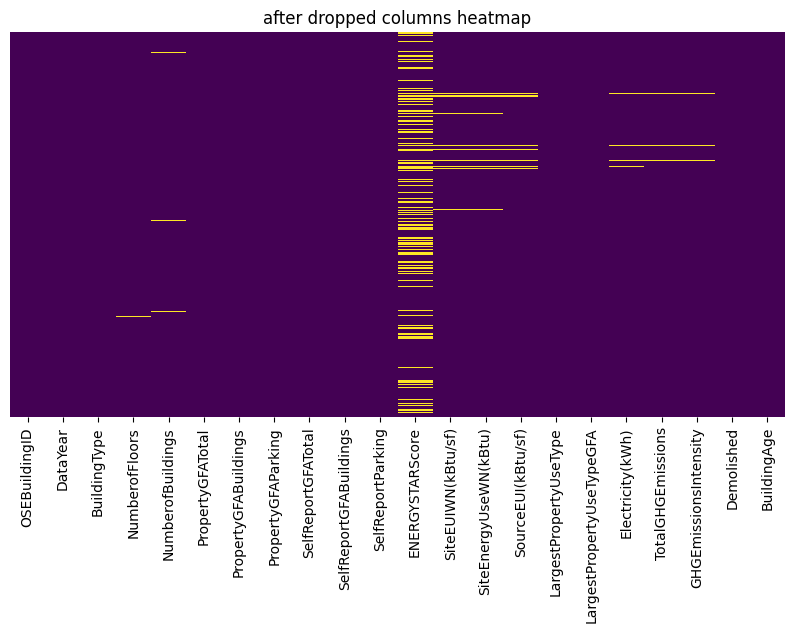

In [137]:
# set figure size
plt.figure(figsize=(10,5))

# create heatmap
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)

# show plot for post-drop columns
plt.title("after dropped columns heatmap")
plt.show()

#### Handling missing values
We replaces all missing values in the ENERGYSTARScore column with 50.
Defines a list of numerical columns that contain missing values and fill them with the median. Median is robust to outliers and is a better choice when the data distribution is skewed.
Fill the missing values in Categorical column with mode (most frequent value in the column)

In [138]:
m_v = df.isnull().sum()
print(m_v[m_v > 0])

NumberofFloors                 83
NumberofBuildings             294
ENERGYSTARScore              7917
SiteEUIWN(kBtu/sf)           1166
SiteEnergyUseWN(kBtu)        1161
SourceEUI(kBtu/sf)            856
LargestPropertyUseType          8
LargestPropertyUseTypeGFA       3
Electricity(kWh)              541
TotalGHGEmissions             457
GHGEmissionsIntensity         459
dtype: int64


In [139]:
# fill missing values with median 50 (according to the description for this column: A score of 50 represents the national median.)
df["ENERGYSTARScore"] = df["ENERGYSTARScore"].fillna(50)
df.isnull().sum()[df.isnull().sum() > 0]

NumberofFloors                 83
NumberofBuildings             294
SiteEUIWN(kBtu/sf)           1166
SiteEnergyUseWN(kBtu)        1161
SourceEUI(kBtu/sf)            856
LargestPropertyUseType          8
LargestPropertyUseTypeGFA       3
Electricity(kWh)              541
TotalGHGEmissions             457
GHGEmissionsIntensity         459
dtype: int64

In [140]:
num_cols = ['NumberofFloors', 'NumberofBuildings', 'SiteEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)',
            'SourceEUI(kBtu/sf)', 'LargestPropertyUseTypeGFA', 'Electricity(kWh)',
            'TotalGHGEmissions', 'GHGEmissionsIntensity']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()[df.isnull().sum() > 0]

LargestPropertyUseType    8
dtype: int64

In [141]:
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].fillna(df['LargestPropertyUseType'].mode()[0])


In [142]:
m_v = df.isnull().sum()
print(m_v[m_v > 0])

Series([], dtype: int64)


### Encoding categorical features
Encode categorical column Demolished with label encoding (Binary Encoding)which will convert True and False values into a numerical values 1 and 0.

For BuildingType feature, there are 8 categories so we would use One-Hot Encoding, because of it's small number of categories will have low impact on dimensionality.

For the LargestPropertyUseType column using One-Hot Encoding can significantly increase the number of columns, especially if you have many unique categories in the categorical variables. There are 65 categories and using this encoding will create an extra 65 new columns to the dataset.This method increases dimensionality and make the model unnecessarily complex. We avoid using this method because of high cardinality and use Frequency Encoding. Frequency encoding replaces categorical values with the proportion (or count) of occurrences in the dataset. It is particularly useful for handling high-cardinality categorical features without increasing dimensionality.



In [143]:
# checking that the Demolished column only contain string value "False" and "True" and not unexpected values like NaN
print(df["Demolished"].unique())

[False  True]


In [144]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for Demolished (Yes → 1, No → 0)
le = LabelEncoder()
df['Demolished'] = le.fit_transform(df['Demolished'])


In [145]:
len(df.columns)
df["BuildingType"].unique()

array(['NonResidential', 'Nonresidential COS', 'Multifamily MR (5-9)',
       'SPS-District K-12', 'Campus', 'Multifamily LR (1-4)',
       'Nonresidential WA', 'Multifamily HR (10+)'], dtype=object)

In [146]:
# count the number of unique values in the columns

print(len(df["BuildingType"].unique()))
print(len(df["LargestPropertyUseType"].unique()))

8
65


In [147]:
df = pd.get_dummies(df, columns=["BuildingType"], drop_first=True)
df = df.astype({col: int for col in df.select_dtypes(include=['bool']).columns})

In [148]:
largest_property_counts = df["LargestPropertyUseType"].value_counts(normalize=True)
df["LargestPropertyUseType"] = df["LargestPropertyUseType"].map(largest_property_counts)

In [149]:
len(df.columns)
df.columns
print(df.dtypes)

OSEBuildingID                          int64
DataYear                               int64
NumberofFloors                       float64
NumberofBuildings                    float64
PropertyGFATotal                       int64
PropertyGFABuildings                   int64
PropertyGFAParking                     int64
SelfReportGFATotal                     int64
SelfReportGFABuildings                 int64
SelfReportParking                      int64
ENERGYSTARScore                      float64
SiteEUIWN(kBtu/sf)                   float64
SiteEnergyUseWN(kBtu)                float64
SourceEUI(kBtu/sf)                   float64
LargestPropertyUseType               float64
LargestPropertyUseTypeGFA            float64
Electricity(kWh)                     float64
TotalGHGEmissions                    float64
GHGEmissionsIntensity                float64
Demolished                             int64
BuildingAge                            int64
BuildingType_Multifamily HR (10+)      int64
BuildingTy

In [150]:
df.to_csv('data/preprocessed_data.csv', index=False)